# β-limited Rates

In [1]:
import pynucastro as pyna

In [2]:
rl = pyna.ReacLibLibrary()

In [3]:
rn14pg = rl.get_rate_by_name("n14(p,g)o15")
ro15betap = rl.get_rate_by_name("o15(,)n15")
ro14betap = rl.get_rate_by_name("o14(,)n14")

In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [5]:
Ts = np.logspace(7, 8.5, 50)

In [6]:
rho = 100
comp = pyna.Composition(["p", "he4", "c12", "n14", "n15", "o15", "o16"],
                        init="solar")

In [7]:
Yp = comp.get_molar()[pyna.Nucleus("p")]

In [8]:
lam_n14pg = [rn14pg.eval(T, rho=rho, comp=comp) for T in Ts]
lam_o15betap = [ro15betap.eval(T, rho=rho, comp=comp) / (rho * Yp) for T in Ts]
lam_o14betap = [ro14betap.eval(T, rho=rho, comp=comp) / (rho * Yp) for T in Ts]

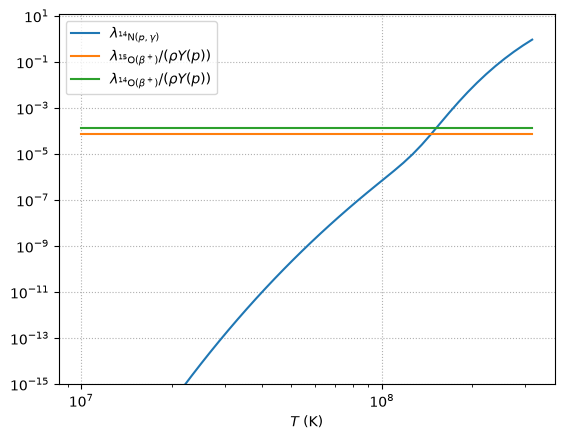

In [9]:
fig, ax = plt.subplots()
ax.loglog(Ts, lam_n14pg, label=r"$\lambda_{{}^{14}\mathrm{N}(p,\gamma)}$")
ax.loglog(Ts, lam_o15betap, label=r"$\lambda_{{}^{15}\mathrm{O}(\beta^+)} / (\rho Y(p))$")
ax.loglog(Ts, lam_o14betap, label=r"$\lambda_{{}^{14}\mathrm{O}(\beta^+)} / (\rho Y(p))$")

ax.grid(ls=":")
ax.set_ylim(1.e-15,)
ax.set_xlabel(r"$T$ (K)")
ax.legend()

In [10]:
rn14pg_betalim = pyna.rates.BetaLimitedRate(rn14pg,
                                            [ro15betap, ro14betap],
                                            limiter_nucleus="p",
                                            description="N14(p,g)O15 limited by O14(β+) and O15(β+)")

In [11]:
lam_n14pg_betalim = [rn14pg_betalim.eval(T, rho=rho, comp=comp) for T in Ts]

In [12]:
ax.loglog(Ts, lam_n14pg_betalim,
          label=r"$\lambda_{{}^{14}\mathrm{N}(p,\gamma)}\, \beta \rm{-limited}$")
ax.legend()

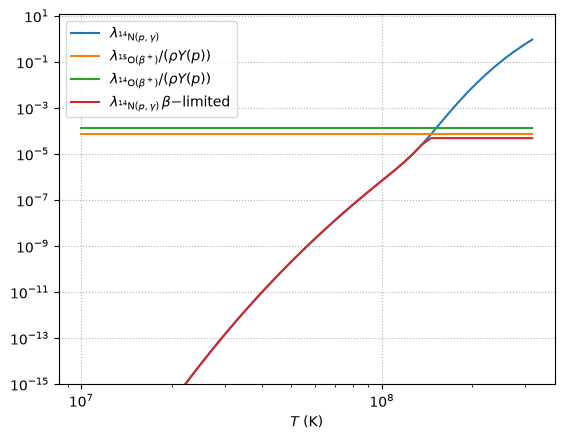

In [13]:
fig

## CNO/hot-CNO approximate network

We can improve the approximate CNO treatment from {doc}`branched-rates` by adding the $\beta$-limiting to capture the transition to hot-CNO.

The normal CNO cycle proceeds as:

$${}^{12}\mathrm{C}(p,\gamma){}^{13}\mathrm{N}(\beta+){}^{13}\mathrm{C}(p,\gamma){}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}(\beta+){}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}$$

and the hot-CNO cycle captures a proton onto ${}^{13}\mathrm{N}$, making ${}^{14}\mathrm{O}$:

$${}^{12}\mathrm{C}(p,\gamma){}^{13}\mathrm{N}(p,\gamma){}^{14}\mathrm{O}(\beta+){}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}(\beta+){}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}$$


At low temperatures, when the normal CNO cycle operates, ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}$ is the bottleneck, and we build up ${}^{14}\mathrm{N}$.

As the temperature rises, we transition to the hot-CNO, and now the rate-limiting
steps in the cycle are the $\beta+$-decays, ${}^{14}\mathrm{O}(,e^+\nu){}^{14}\mathrm{N}$ and ${}^{15}\mathrm{O}(,e^+\nu){}^{15}\mathrm{N}$, whose decay
times are comparable.  So we want to limit the overall flow through the entire cycle by those waiting points.

`aprox19` uses 4 effective rates:

  1. ${}^{12}\mathrm{C}(p,\gamma){}^{13}\mathrm{N}(\beta^+)
     {}^{13}\mathrm{C}(p,\gamma){}^{14}\mathrm{N}$

     
     Net: ${}^{12}\mathrm{C}+2p\rightarrow{}^{14}\mathrm{N}$

  2. ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}(\beta^+)
     {}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}$

     
     Net: ${}^{14}\mathrm{N}+2p\rightarrow{}^{12}\mathrm{C}+\alpha$

  3. ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}(\beta^+)
     {}^{15}\mathrm{N}(p,\gamma){}^{16}\mathrm{O}$
     
     Net: ${}^{14}\mathrm{N}+2p\rightarrow{}^{16}\mathrm{O}$

  4. ${}^{16}\mathrm{O}(p,\gamma){}^{17}\mathrm{F}(\beta^+)
     {}^{17}\mathrm{O}(p,\alpha){}^{14}\mathrm{N}$
     
     Net: ${}^{16}\mathrm{O}+2p\rightarrow{}^{14}\mathrm{N}+\alpha$

Sequences 1 and 2 represent the normal CNO cycle.  

Sequence 3 is an alternate branch, and sequence 4 represents part of the CNO-II cycle.  Without it, we
would build up ${}^{16}\mathrm{O}$, which is unphysical.

### Where to β-limit?

Now for hot-CNO, we want to $\beta$-limit the overall sequence from ${}^{12}\mathrm{C}$ back to ${}^{12}\mathrm{C}$.  The `aprox19` network chooses
to put the waiting into sequences 2 and 3, by capping the ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}$ rate.  In this sense, it keeps ${}^{14}\mathrm{N}$
as the bottleneck nucleus (we don't have ${}^{14}\mathrm{O}$ or ${}^{15}\mathrm{O}$ in our network, so we can't use them as the bottleneck).

We could instead choose to limit cycle 1 by ${}^{14}\mathrm{O}(\beta+){}^{14}\mathrm{N}$, which would split the bottleneck nucleus up between
${}^{12}\mathrm{C}$ and ${}^{14}\mathrm{N}$ (in an amount relative to the ${}^{14}\mathrm{O}$ and ${}^{15}\mathrm{O}$ waiting times).  But this is not the path
the original approximation took.  So we will put all the waiting into ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}$.


We will also $\beta$-limit the ${}^{16}\mathrm{O}(p,\gamma){}^{17}\mathrm{F}$ rate.

We will use our $beta$-limited rate for constructing our branched rates.

In [14]:
from pynucastro import Nucleus

In [15]:
rc12pg = rl.get_rate_by_name("c12(p,g)n13")
rn15pa = rl.get_rate_by_name("n15(p,a)c12")
rn15pg = rl.get_rate_by_name("n15(p,g)o16")
ro16pg = rl.get_rate_by_name("o16(p,g)f17")
rf17betap = rl.get_rate_by_name("f17(,)o17")

Our effective rate for ${}^{12}\mathrm{C}+2p\rightarrow{}^{14}\mathrm{N}$ is unchanged from our earlier approximation.

In [16]:
rc12_2p_n14 = pyna.ModifiedRate(rc12pg,
                                new_products=[Nucleus("n14")],
                                stoichiometry={Nucleus("p"): 2})

Now the ${}^{14}\mathrm{N} + 2p$ branches.  These will use our new $\beta$-limited rate constructed above

In [17]:
rn14_2p_c12 = pyna.BranchedRate(rn14pg_betalim,
                                primary_branch=rn15pa,
                                other_branch=rn15pg,
                                stoichiometry={Nucleus("p"): 2},
                                description="N14(p,g)O15(,e+nu)N15(p,a)C12")

In [18]:
rn14_2p_o16 = pyna.BranchedRate(rn14pg_betalim,
                                primary_branch=rn15pg,
                                other_branch=rn15pa,
                                stoichiometry={Nucleus("p"): 2},
                                description="N14(p,g)O15(,e+nu)N15(p,g)O16")

In [19]:
print(rn14_2p_c12.function_string_py())

@numba.njit()
def N14_p_p_to_He4_C12_beta_pos_branched(rate_eval, tf, log_scor=0.0):
    # N14 + p + p --> He4 + C12
    # represents the sequence: N14(p,g)O15(,e+nu)N15(p,a)C12

    r0 = rate_eval.N14_p_to_O15_betalimited
    r_prim_br = rate_eval.N15_p_to_He4_C12_reaclib
    r_other_br = rate_eval.N15_p_to_O16_reaclib

    f = r_prim_br / (r_prim_br + r_other_br)
    rate_eval.N14_p_p_to_He4_C12_beta_pos_branched = f * r0




In [20]:
print(rn14pg_betalim.function_string_py())

@numba.njit()
def N14_p_to_O15_betalimited(rate_eval, tf, rho=None, Y=None, log_scor=0.0):
    # N14 + p --> O15
    # represents the beta limiting: N14(p,g)O15 limited by O14(β+) and O15(β+)

    r0 = rate_eval.N14_p_to_O15_reaclib
    lambda_beta_tot = 0.0
    lambda_beta_tot += 1.0 / rate_eval.O15_to_N15_beta_pos_reaclib
    lambda_beta_tot += 1.0 / rate_eval.O14_to_N14_beta_pos_reaclib
    lambda_beta_tot = 1.0 / lambda_beta_tot

    limited_rate = min(r0, lambda_beta_tot / (rho * Y[jp]))
    rate_eval.N14_p_to_O15_betalimited = limited_rate




Finally for ${}^{16}\mathrm{O} + 2 p \rightarrow {}^{14}\mathrm{N} + \alpha$
we first $\beta$-limit the initial rate in the sequence.

In [21]:
ro16pg_betalim = pyna.rates.BetaLimitedRate(ro16pg,
                                            [rf17betap],
                                            limiter_nucleus="p",
                                            description="O16(p,g)F17 limited by F17(β+)")

In [22]:
ro16_2p_n14_a = pyna.ModifiedRate(ro16pg_betalim,
                                  new_products=[Nucleus("n14"),
                                                Nucleus("he4")],
                                  stoichiometry={Nucleus("p"): 2})

In [23]:
net_reduced = pyna.PythonNetwork(rates=[rc12_2p_n14,
                                        rn14_2p_c12,
                                        rn14_2p_o16,
                                        ro16_2p_n14_a])

In [24]:
net_reduced.summary()

Network summary
---------------
  explicitly carried nuclei: 5
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 14

  rates explicitly connecting nuclei: 4
  hidden rates: 5

  reaclib rates: 8
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 0
  beta-limited rates: 2
  approximate rates: 0
  derived rates: 0
  branched rates: 2
  modified rates: 2
  custom rates: 0


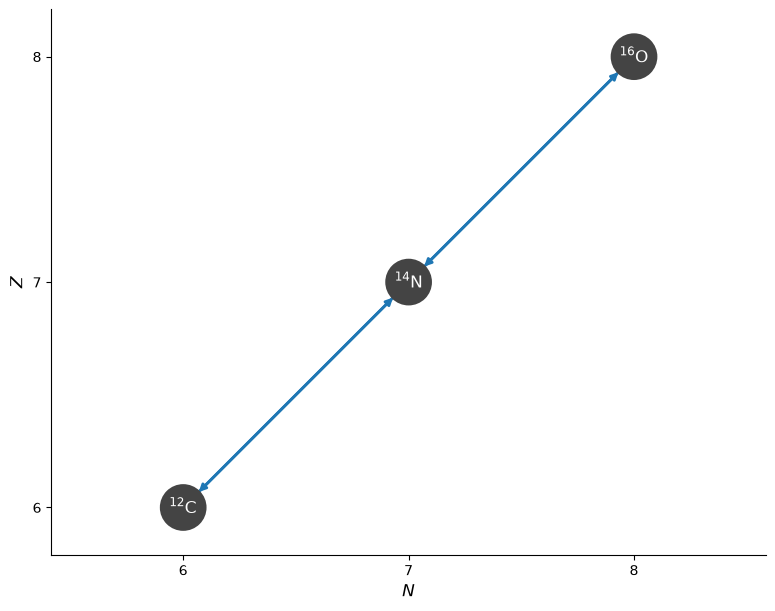

In [25]:
fig = net_reduced.plot()

In [26]:
comp_reduced = pyna.Composition(net_reduced.unique_nuclei, small=0.0)
comp_reduced[Nucleus("p")] = 0.74
comp_reduced[Nucleus("he4")] = 0.24
comp_reduced[Nucleus("c12")] = 0.003
comp_reduced[Nucleus("n14")] = 0.001
comp_reduced[Nucleus("o16")] = 0.016

In [27]:
rho = 100
T = 2.e7

In [28]:
tmax = 1.e20

In [29]:
sol_reduced = net_reduced.integrate_network(tmax, rho, T, comp_reduced)

/home/zingale/.local/lib/python3.14/site-packages/scipy/_lib/_util.py:1138: LinAlgWarning: Diagonal number 5 is exactly zero. Singular matrix.
  return f(*arrays, *other_args, **kwargs)


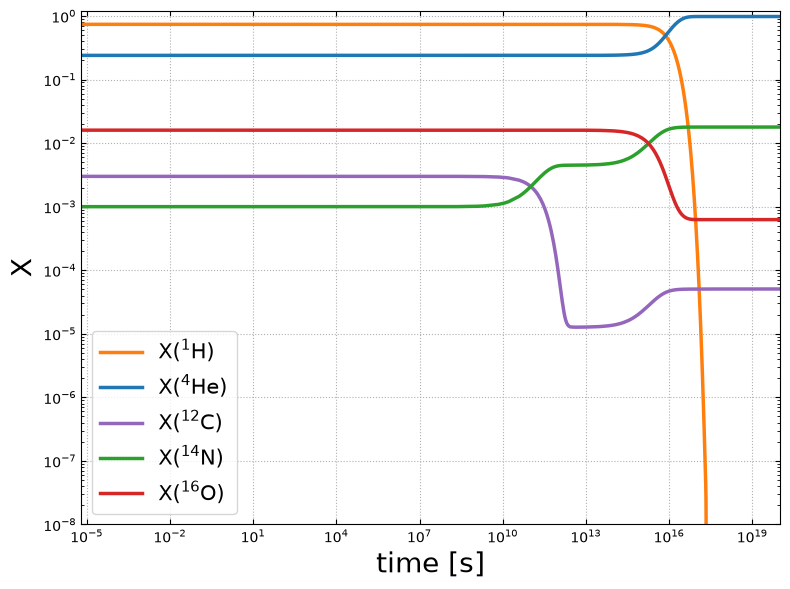

In [38]:
fig = sol_reduced.plot_evolution(ymin=1.e-8)

In [30]:
net_reduced.write_network("test.py")

In [31]:
net_reduced.reaclib_rates

[C12 + p ⟶ N13 + 𝛾,
 N14 + p ⟶ O15 + 𝛾,
 O15 ⟶ N15 + e⁺ + 𝜈,
 O14 ⟶ N14 + e⁺ + 𝜈,
 N15 + p ⟶ He4 + C12,
 N15 + p ⟶ O16 + 𝛾,
 O16 + p ⟶ F17 + 𝛾,
 F17 ⟶ O17 + e⁺ + 𝜈]

In [32]:
rn14pg_betalim.get_child_rates()

[N14 + p ⟶ O15 + 𝛾, O15 ⟶ N15 + e⁺ + 𝜈, O14 ⟶ N14 + e⁺ + 𝜈]

In [33]:
for r in rn14pg_betalim.get_child_rates():
    print(r, type(r).__name__)

N14 + p ⟶ O15 + 𝛾 ReacLibRate
O15 ⟶ N15 + e⁺ + 𝜈 ReacLibRate
O14 ⟶ N14 + e⁺ + 𝜈 ReacLibRate


In [34]:
net_reduced._build_collection()

In [35]:
for r in net_reduced.get_rates():
    print(r, type(r).__name__)

C12 + p + p ⟶ N14 + e⁺ + 𝜈 ModifiedRate
N14 + p + p ⟶ He4 + C12 + e⁺ + 𝜈 BranchedRate
N14 + p + p ⟶ O16 + e⁺ + 𝜈 BranchedRate
O16 + p + p ⟶ N14 + He4 + e⁺ + 𝜈 ModifiedRate


In [36]:
net_reduced.reaclib_rates

[C12 + p ⟶ N13 + 𝛾,
 N14 + p ⟶ O15 + 𝛾,
 O15 ⟶ N15 + e⁺ + 𝜈,
 O14 ⟶ N14 + e⁺ + 𝜈,
 N15 + p ⟶ He4 + C12,
 N15 + p ⟶ O16 + 𝛾,
 O16 + p ⟶ F17 + 𝛾,
 F17 ⟶ O17 + e⁺ + 𝜈]